In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
# Ensure the CSV path matches your local file location
df = pd.read_csv("Data/news_articles.csv")

# Display shape and basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2096, 12)


,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
1,reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
2,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
3,Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
4,Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [41]:
# pre processing and cleaning

# 1. Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Drop rows with missing text or labels to avoid errors
df = df.dropna(subset=['text', 'title', 'label'])

# 3. Create a unified 'content' column (Title + Text)
df['content'] = df['title'] + " " + df['text']

# 4. Standardize the labels
# We want to see what unique labels exist (e.g., 'Real', 'Fake')
print("\nUnique Labels found:", df['label'].unique())

# (Optional) If your labels are not just 'Real'/'Fake', you might need to map them.
# For this code, we assume the dataset has 'Real' and 'Fake' (or similar distinct classes).

Missing values before cleaning:
author                      0
published                   0
title                       0
text                       46
language                    1
site_url                    1
main_img_url                1
type                        1
label                       1
title_without_stopwords     2
text_without_stopwords     50
hasImage                    1
dtype: int64

Unique Labels found: ['Real' 'Fake']


/tmp/ipykernel_5387/1713668502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


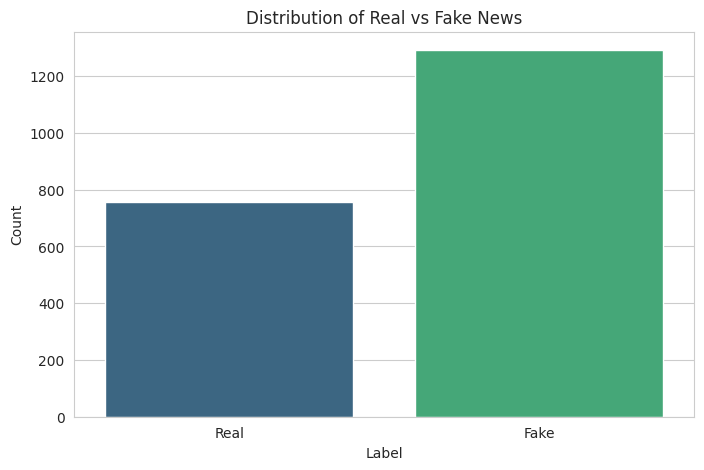

label
Fake    1292
Real     758
Name: count, dtype: int64


In [42]:
# Set plot style
sns.set_style("whitegrid")

# 1. Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Real vs Fake News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()



# 2. Check data balance programmatically
print(df['label'].value_counts())

In [43]:
# --- Feature Engineering ---

# 1. First, ensure the 'content' column exists
# (This combines the Title and Text into one column)
df['content'] = df['title'] + " " + df['text']

# 2. Now create the new columns for analysis
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
df['title_length'] = df['title'].apply(lambda x: len(str(x)))

print("Added 'word_count' and 'title_length' columns.")

Added 'word_count' and 'title_length' columns.


Text(0.5, 1.0, 'Title Length vs Word Count')

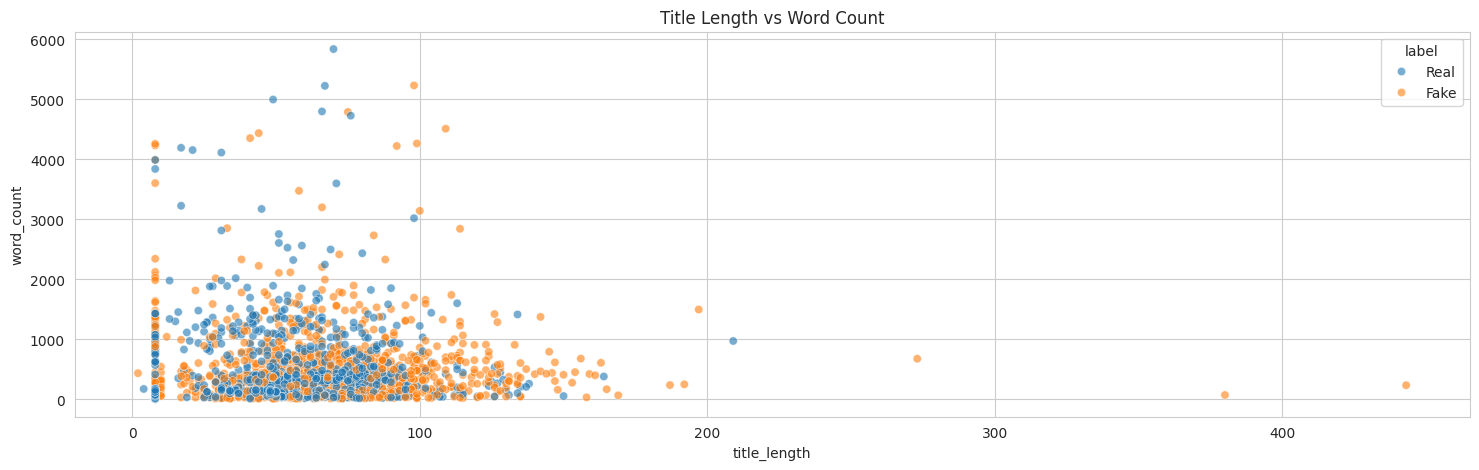

In [44]:
# 1. Numerical-Numerical: Title Length vs Word Count
sns.set_style("whitegrid")
plt.figure(figsize=(18, 5))
sns.scatterplot(x='title_length', y='word_count', hue='label', data=df, alpha=0.6)
plt.title('Title Length vs Word Count')

Text(0.5, 1.0, 'Word Count by Label')

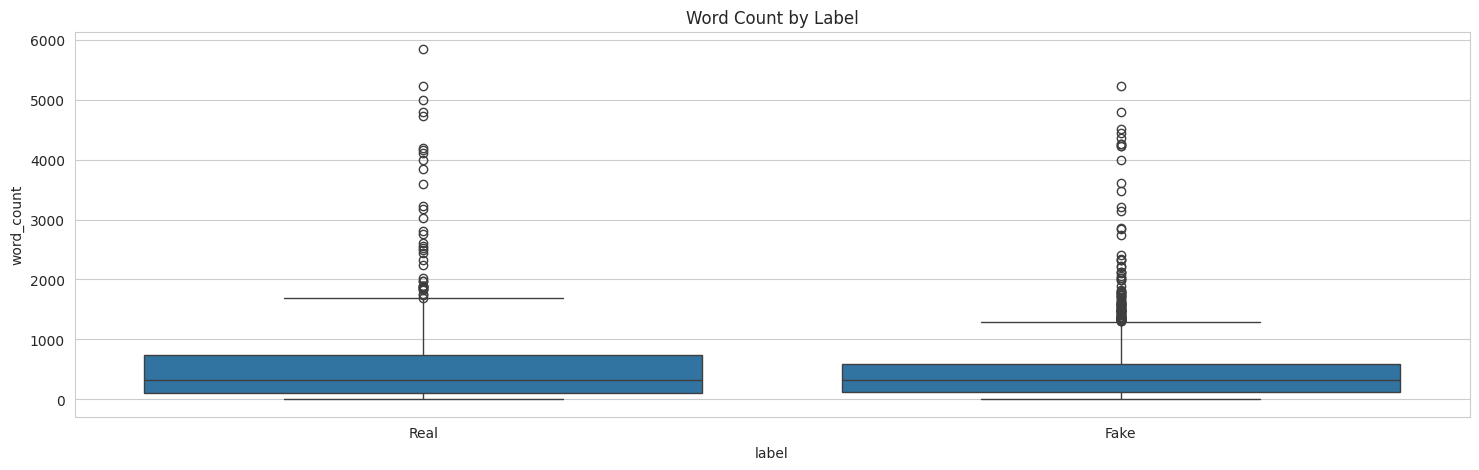

In [45]:
# 2. Categorical-Numerical: Label vs Word Count
sns.set_style("whitegrid")
plt.figure(figsize=(18, 5))
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count by Label')

Text(0.5, 1.0, 'Image Presence by Label')

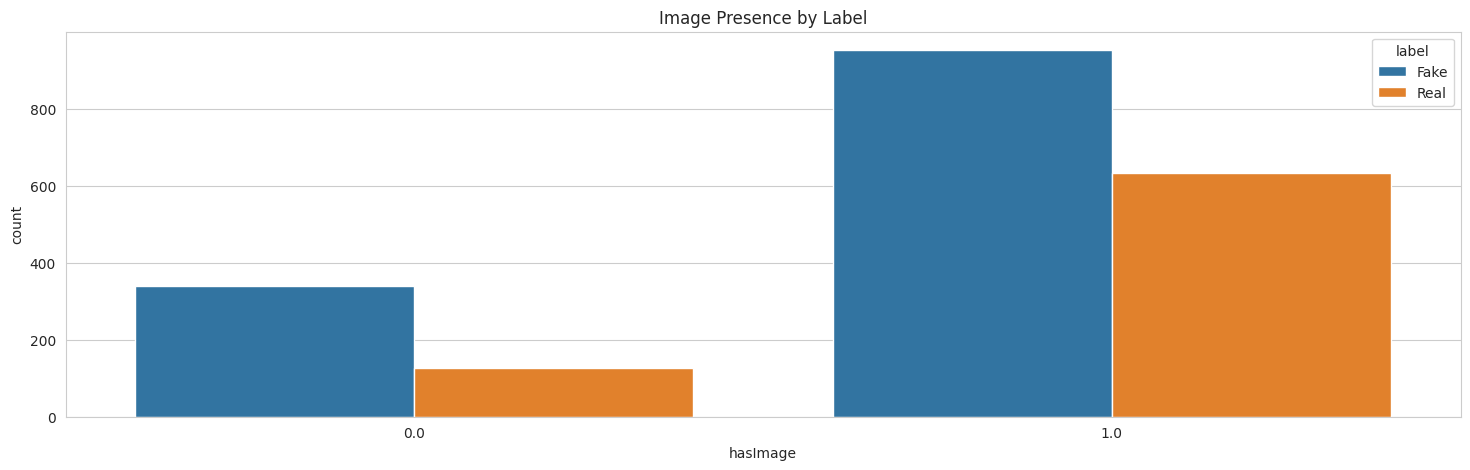

In [46]:
# 3. Categorical-Categorical: Label vs hasImage
sns.set_style("whitegrid")
plt.figure(figsize=(18, 5))
sns.countplot(x='hasImage', hue='label', data=df)
plt.title('Image Presence by Label')

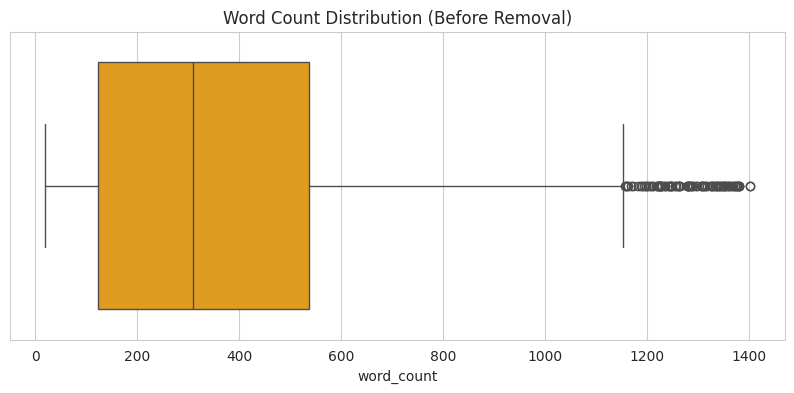

Removed 89 outlier rows.


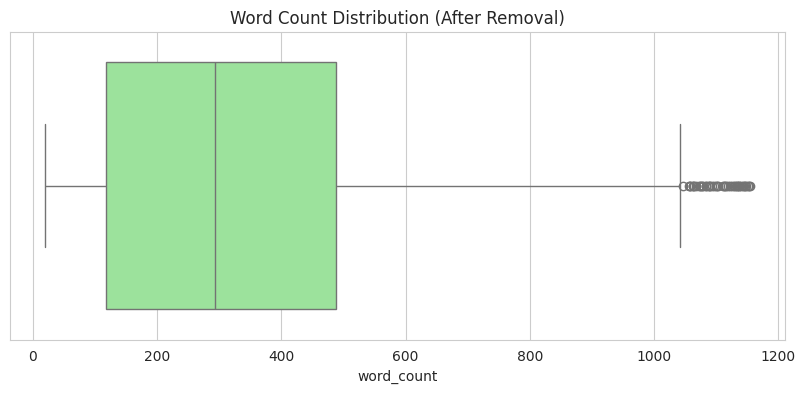

In [55]:
# --- Outlier Detection & Removal ---

# 1. Visualize outliers first
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['word_count'], color='orange')
plt.title('Word Count Distribution (Before Removal)')
plt.show()

# 2. Calculate IQR to define what is an outlier
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR  # Remove articles with fewer than 20 words (likely errors)
upper_bound = Q3 + 1.5 * IQR # Standard statistical upper bound

# 3. Remove the outliers
original_count = df.shape[0]
df_clean = df[(df['word_count'] >= lower_bound) & (df['word_count'] <= upper_bound)]
rows_removed = original_count - df_clean.shape[0]

print(f"Removed {rows_removed} outlier rows.")

# 4. Update the dataframe
df = df_clean.reset_index(drop=True)

# 5. Verify Removal
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['word_count'], color='lightgreen')
plt.title('Word Count Distribution (After Removal)')
plt.show()

In [48]:
#text normalization
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove numbers / digits
    text = re.sub(r'\d+', '', text)
    # Remove newlines
    text = re.sub(r'\n', ' ', text)
    return text

# Apply cleaning to the content column
print("Cleaning text data... this may take a moment.")
df['content'] = df['content'].apply(clean_text)

print("Text cleaning complete.")
df[['content', 'label']].head()

Cleaning text data... this may take a moment.
Text cleaning complete.


,content,label
0,muslims busted they stole millions in govt ben...,Real
1,re why did attorney general loretta lynch plea...,Real
2,breaking weiner cooperating with fbi on hillar...,Real
3,pin drop speech by father of daughter kidnappe...,Real
4,fantastic trumps point plan to reform healthc...,Real


In [49]:
#split data and vectorization

# Define Features (X) and Target (y)
X = df['content']
y = df['label']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer
# max_df=0.7 means ignore terms that appear in more than 70% of documents (too common)
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit and transform the training data, transform the test data
tfidf_train = vectorizer.fit_transform(X_train)
tfidf_test = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Vocabulary size: 35184


In [63]:
#model training 


# # Initialize the model
# model = PassiveAggressiveClassifier(max_iter=50)

# # Train the model
# model.fit(tfidf_train, y_train)

# naive bayes 
# # print("Model training complete.")
# from sklearn.naive_bayes import MultinomialNB

# # 1. Initialize the Multinomial Naive Bayes model
# model = MultinomialNB()

# # 2. Train the model
# model.fit(tfidf_train, y_train)

# print("Naive Bayes model training complete.")

# # 3. (Optional) Immediately check accuracy
# y_pred = model.predict(tfidf_test)
# score = accuracy_score(y_test, y_pred)
# print(f'Naive Bayes Accuracy: {round(score*100, 2)}%')

#SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# 1. Initialize Linear SVC
# random_state=42 ensures you get the same result every time you run it
model = LinearSVC(random_state=42)

# 2. Train the model
model.fit(tfidf_train, y_train)

print("SVM (LinearSVC) model training complete.")

# 3. Check accuracy
y_pred = model.predict(tfidf_test)
score = accuracy_score(y_test, y_pred)
print(f'SVM Accuracy: {round(score*100, 2)}%')

SVM (LinearSVC) model training complete.
SVM Accuracy: 80.21%


Accuracy: 68.72%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.68      1.00      0.81       243
        Real       0.94      0.11      0.20       131

    accuracy                           0.69       374
   macro avg       0.81      0.56      0.50       374
weighted avg       0.77      0.69      0.59       374



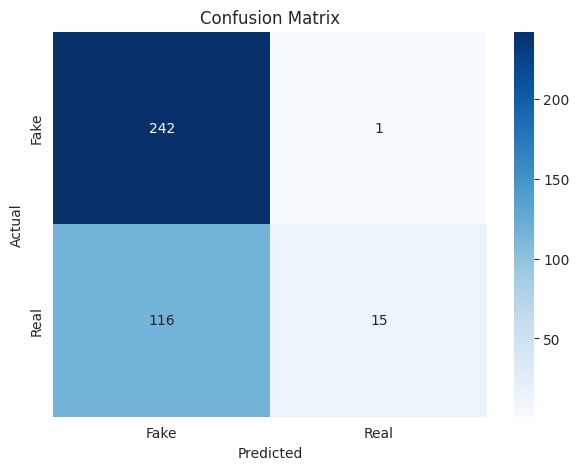

In [61]:
#evaluation 

# Predict on the test set
y_pred = model.predict(tfidf_test)

# Calculate Accuracy
score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(score*100, 2)}%')

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [68]:
def predict_news(news_text):
    # 1. Clean the input text using the same function as before
    cleaned_text = clean_text(news_text)
    
    # 2. Transform the text using the ALREADY FITTED vectorizer
    # Note: Do not use fit_transform here, only transform
    input_vector = vectorizer.transform([cleaned_text])
    
    # 3. Predict
    prediction = model.predict(input_vector)
    
    return prediction[0]

# --- TEST IT HERE ---
user_input = input("Enter a news article text to check: ")

if user_input:
    result = predict_news(user_input)
    print(f"\n---------------------------------")
    print(f"The model predicts this news is: **{result}**")
    print(f"---------------------------------")

Enter a news article text to check:  india declares war on russia



---------------------------------
The model predicts this news is: **Fake**
---------------------------------
